In [22]:
import navis 
import os 
import numpy as np 
import pandas as pd 
import pickle 
from multiprocessing import Pool
from fafbseg import flywire
import matplotlib.pyplot as plt 
import matplotlib
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))

from cell_groups import *
atGRN_cluster = pd.read_parquet(
    REPO_ROOT / "data" / "atGRN_cluster_info_v783.parquet"
)
atgrn_c2g = {}
for t in np.unique(atGRN_cluster.type):
    atgrn_c2g[t] = list(atGRN_cluster.flyid.values[atGRN_cluster.type==t])
atGRN_candi = atGRN_cluster.flyid.values

earmuff = sez['earmuff']

matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
fontsize = 7


mat_atGRN_earmuff = pd.read_parquet('atGRN_candi_to_earmuff.parquet')
mat_atGRN_earmuff_like = mat_atGRN_earmuff[[720575940611411057,720575940635642725]]


In [23]:
cells = atGRN_cluster.flyid.values
groups = atGRN_cluster.type.values

_, group_idx = np.unique(groups, return_inverse=True)
cidx_g = np.array(list(dict.fromkeys(group_idx)))
unique_groups = np.unique(group_idx)

mat_group = np.zeros((len(unique_groups), mat_atGRN_earmuff_like.shape[1]))

for i, g in enumerate(unique_groups):
    mat_group[i] = mat_atGRN_earmuff_like[group_idx == g].mean(axis=0)

mat_group = pd.DataFrame(
    mat_group,
    index=[f"a{i}" for i in range(1, len(unique_groups) + 1)],
    columns=mat_atGRN_earmuff_like.columns,
)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

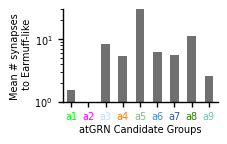

In [27]:
fig,ax= plt.subplots(1,1,figsize=(2,1.2))
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
lp = 2 


df_total = mat_group.sum(axis=1)
df_total.plot.bar(ax=ax,color=['#717070'] ,bottom=1)#color=['#7D7C7C','#B4B4B8']
ax.set_yscale('log')

yticks = [10**x for x in list(range(0,3,1))]#[2**i for i in range(0, int(np.ceil(np.log2(np.max(df.values)))) + 1)]
yticks_label = [f"$10^{{{n}}}$" for n in list(range(0,3,1))]
ax.set_yticks(yticks,yticks,fontsize=fontsize)
ax.set_yticklabels(yticks_label, fontsize=fontsize)  

ax.set_xticklabels(
    mat_group.index,
    fontsize=fontsize,
)

_,cidx = np.unique(groups,return_inverse=True)
group_colors = list(dict.fromkeys(atGRN_cluster.color))
for i,tick in enumerate(ax.get_xticklabels()):
    tick.set_color(group_colors[cidx_g[i]])
ax.tick_params('x',rotation=0)
ax.set_ylabel('Mean # synapses\n to Earmuff-like',fontsize=fontsize,labelpad=lp)
ax.set_xlabel('atGRN Candidate Groups',fontsize=fontsize,labelpad=lp)
ax.set_ylim(bottom=1, top=30)  
ax.tick_params(axis='both', width=1)

ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_linewidth(1)
plt.savefig(f'mean_synapses_to_earmuff_like.svg',bbox_inches='tight')